In [169]:
#Question 1
import pandas as pd
import numpy as np


df = pd.read_csv('/content/drive/MyDrive/RealEstate_Georgia.csv')


print(df.head())
print()
print("Shape of the DataFrame is:",df.shape)

print()
print(df.dtypes)



   Unnamed: 0                id  stateId  countyId  cityId country  \
0           0   31503-110785431       16        17   55064     USA   
1           1    31503-76611082       16        18   55064     USA   
2           2    31503-93126153       16        19   55064     USA   
3           3   31503-110785598       16        20   55064     USA   
4           4  31503-2101070583       16        21   55064     USA   

  datePostedString  is_bankOwned  is_forAuction            event  ...  \
0       2021-07-12             0              0  Listed for sale  ...   
1       2021-07-12             0              0  Listed for sale  ...   
2       2021-07-10             0              0  Listed for sale  ...   
3       2021-07-09             0              0  Listed for sale  ...   
4       2021-07-06             0              0  Listed for sale  ...   

   parking  garageSpaces  hasGarage levels pool  spa isNewConstruction  \
0        0           0.0          0      0    0    0              

#Question 1 Continued
#
My problem statement for this question is: How do property characteristics combine to determine home sale prices in Georgia, and which factors are most influential?
#
Throughout this project, my goal is to determine which characteristics impact home sale prices in Georgia the most. In doing so, I hope to provide specific characteristics that consumers can use to find the best possible home price.
#
The target variable for this project is:"price".
#
Describe the dataset: This data covers Georgia real estate data from the first six months of 2021. There are 39 columns and 13,804 homes listed. The variables contain things like "description", "yearBuilt", "homeType", etc. Next, I will go through the data and clean it as well as determining which columns are necessary.   

In [170]:
#Question 2
#Basic data cleaning
# See all column names
print("All columns in the dataset:")
print(df.columns.tolist())
print("Total columns:", {len(df.columns)})

# See first few rows to understand the data
print("First 5 rows:")
print(df.head())

# Check data types
print("Data types:")
print(df.dtypes)

All columns in the dataset:
['Unnamed: 0', 'id', 'stateId', 'countyId', 'cityId', 'country', 'datePostedString', 'is_bankOwned', 'is_forAuction', 'event', 'time', 'price', 'pricePerSquareFoot', 'city', 'state', 'yearBuilt', 'streetAddress', 'zipcode', 'longitude', 'latitude', 'hasBadGeocode', 'description', 'currency', 'livingArea', 'livingAreaValue', 'lotAreaUnits', 'bathrooms', 'bedrooms', 'buildingArea', 'parking', 'garageSpaces', 'hasGarage', 'levels', 'pool', 'spa', 'isNewConstruction', 'hasPetsAllowed', 'homeType', 'county']
Total columns: {39}
First 5 rows:
   Unnamed: 0                id  stateId  countyId  cityId country  \
0           0   31503-110785431       16        17   55064     USA   
1           1    31503-76611082       16        18   55064     USA   
2           2    31503-93126153       16        19   55064     USA   
3           3   31503-110785598       16        20   55064     USA   
4           4  31503-2101070583       16        21   55064     USA   

  datePo

#Question 2 Continued
#
The first thing I am going to do is look at all the columns and see if there are any that I can immediately drop before I do anything else.
#
The first columns that come to mind are: 'Unnamed: 0', 'id' 'stateId',        'countyId', 'cityId', 'country'. These can be dropped because they are simply id's that will have no impact on our target variable. I can drop country because it is the same for every house on the market. "state" and "currency" can be dropped for the same reason.
#
The other columns I am going to drop are: 'datePostedString', 'time',     'event', 'currency', 'state', 'streetAddres', 'hasBadGeocode',      'description', 'pricePerSquareFoot', 'livingAreaValue',   'buildingArea',     'lotAreaUnits'
#
These columns are not helpful in finding the factors that contribute to price.

In [171]:
#Question 2 Continued
#Drop the columns we don't need

columns_to_drop = [
    'Unnamed: 0','id', 'stateId','countyId', 'cityId','country',
    'datePostedString','time','event','currency','state',
    'streetAddress','hasBadGeocode','description','pricePerSquareFoot',
    'livingAreaValue','buildingArea','lotAreaUnits', 'longitude', 'latitude', 'city', 'zipcode']

df_cleaned = df.drop(columns_to_drop, axis=1)
print(df_cleaned.head())
print(df_cleaned.shape)
print(df_cleaned.columns.tolist())

   is_bankOwned  is_forAuction     price  yearBuilt  livingArea  bathrooms  \
0             0              0  169900.0       1985      2302.0        3.0   
1             0              0  159000.0       1910      2864.0        2.0   
2             0              0   45000.0       1945       728.0        1.0   
3             0              0  165000.0       1971      1620.0        2.0   
4             0              0  128593.0          0         0.0        0.0   

   bedrooms  parking  garageSpaces  hasGarage levels  pool  spa  \
0       4.0        0           0.0          0      0     0    0   
1       4.0        0           0.0          0      0     0    0   
2       1.0        1           0.0          0      0     0    0   
3       2.0        0           0.0          0      0     0    0   
4       0.0        0           0.0          0      0     0    0   

   isNewConstruction  hasPetsAllowed       homeType           county  
0                  0               0  SINGLE_FAMILY  Bran

In [172]:
#Question 2 Continued:
#Now that I have eliminated columns I know I do not need, I will move to checking for null values
print("Null values: \n", df_cleaned.isnull().sum())

Null values: 
 is_bankOwned         0
is_forAuction        0
price                0
yearBuilt            0
livingArea           0
bathrooms            0
bedrooms             0
parking              0
garageSpaces         0
hasGarage            0
levels               0
pool                 0
spa                  0
isNewConstruction    0
hasPetsAllowed       0
homeType             0
county               0
dtype: int64


In [173]:
#Question 2 Continued:
#Since I found no null values, I will now check for duplicates

print("Total rows before removing duplicates:", len(df_cleaned))
print("Number of duplicate rows: ", df_cleaned.duplicated().sum())

# Drop duplicate rows
df_cleaned = df_cleaned.drop_duplicates()

print("Number of duplicate rows after dropping: ", df_cleaned.duplicated().sum())

Total rows before removing duplicates: 13804
Number of duplicate rows:  2046
Number of duplicate rows after dropping:  0


In [174]:
#Question 2 Continued:
#Now with duplicates removed, I will check for inconsistent inputs for categorical variables

# Check categorical columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

print("Categorical Columns:")
for col in categorical_cols:
    print(col)
    print(df_cleaned[col].value_counts())





Categorical Columns:
levels
levels
0                                      5328
One                                    2609
Two                                    2472
Three Or More                           580
One and One Half                        433
Multi/Split                             197
2 Story or More                          51
Two-Two Story Foyer                       8
Tri Level                                 7
One-One and One Half                      6
Split Level                               5
Split Foyer                               5
One-Two                                   5
3 Story                                   5
Other-See Remarks                         4
Two-Foyer - 2 Story                       3
Multi/Split-Split Level                   3
Two-Multi/Split                           3
Three Or More-Two Story Foyer             3
One-Mobile Home 1 Story                   2
Multi/Split-Two                           2
One and One Half-Multi/Split             

In [175]:
#Question 2 Continued:
#What is concerning me about the levels category is that the levels are not consistent.
#I will now convert the levels to more consistent values.
df_cleaned['levels'] = df_cleaned['levels'].replace({
    '0': 'Unknown',
    'One': '1',
    'Two': '2',
    'Three Or More': '3+',
    'One and One Half': '1.5',
    '2.5 Story': '2.5',
    '3 Story': '3+',
    'Multi/Split': 'Split',
    'Tri Level': 'Split',
    'Tri-Level': 'Split',
    'Split Level': 'Split',
    'Split Foyer': 'Split',
    '2 Story or More': '2+',
    'Over 2 Stories': '2+',
    'Two and One-Half': '2.5',
    'One-One and One Half': '1.5',
    'One-Two': '1',
    'Other-See Remarks': 'Other',
    'Two-Multi/Split': 'Split',
    'Multi/Split-Split Level': 'Split',
    'Two-Foyer - 2 Story': '2',
    'Three Or More-Two Story Foyer': '3+',
    'One and One Half-Multi/Split': 'Split',
    'One and One Half-Two': '1.5',
    'One-Manufactured Home 1 Story': '1',
    'Two-Three Or More': '2',
    'Two-Split Foyer': 'Split',
    'One-Mobile Home 1 Story': '1',
    'Manufactured Home 1 Story': '1',
    'Split Foyer-Split Level': 'Split',
    'One and One Half-Split Level': 'Split',
    'One-Two Story Foyer': '1',
    'Three Or More-Split Level-Tri-Level': 'Split',
    'Split Level-Two': 'Split',
    'One-One and One Half-Two': '1.5',
    'One-Other': 'Other',
    'Two-Split Level': 'Split',
    'Tri Level-Split Level': 'Split',
    'One-Two-Mobile Home 1 Story': '1',
    'Multi/Split-Two': 'Split'



})
print(df_cleaned['levels'].value_counts())


levels
Unknown                5328
1                      2621
2                      2477
3+                      588
1.5                     442
Split                   234
2+                       52
Two-Two Story Foyer       8
Other                     5
2.5                       3
Name: count, dtype: int64


After running the boxplots and histogram for the first time, I quickly realized that there were some odd values skewing the data. For example, the max value for year built is "9999". The max value for bathrooms was "89". There is some more data cleaning that I need to do before continuing further.

In [176]:
#Question 2 Continued:
#There is a large number of '0' values in the 'yearBuilt' column.
#This is likely because a large number of homes are actually empty lots
#I am going to drop 'lots" from the 'homeType' column.

df_cleaned = df_cleaned[df_cleaned['homeType'] != 'LOT']

In [177]:
#After looking at the data and visualizing it through graphs, I realized there where a lot of outliers.
#To fix this, I filtered out some of the high and unrealistic values using the following code.
#This cleaned up a lot of the outliers and incorrect data.
df_filtered = df_cleaned.copy()

print(f"Starting rows: {len(df_filtered)}")

# Remove unrealistic values
df_filtered = df_filtered[
    (df_filtered['price'] > 0) &                    # Price must be > 0
    (df_filtered['price'] < 2500000) &              # Reasonable max price for GA
    (df_filtered['yearBuilt'] >= 1850) &            # Oldest realistic home
    (df_filtered['yearBuilt'] <= 2021) &            # Data is from 2021
    (df_filtered['livingArea'] > 0) &               # Must have living area
    (df_filtered['livingArea'] < 9000) &           # Reasonable max sq ft
    (df_filtered['bathrooms'] >= 0) &
    (df_filtered['bathrooms'] <= 10) &              # Max 10 bathrooms
    (df_filtered['bedrooms'] >= 0) &
    (df_filtered['bedrooms'] <= 10) &               # Max 10 bedrooms
    (df_filtered['garageSpaces'] <= 5)              # Max 5 garage spaces
]

print(f"Rows after filtering: {len(df_filtered)}")
print(f"Rows removed: {len(df_cleaned) - len(df_filtered)}")

# Check the cleaned data
print("\nCleaned data statistics:")
for col in ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms']:
    print(f"\n{col}:")
    print(df_filtered[col].describe())

Starting rows: 8163
Rows after filtering: 7214
Rows removed: 949

Cleaned data statistics:

price:
count    7.214000e+03
mean     3.871597e+05
std      3.050532e+05
min      7.950000e+02
25%      1.999000e+05
50%      3.139000e+05
75%      4.749000e+05
max      2.499999e+06
Name: price, dtype: float64

yearBuilt:
count    7214.000000
mean     1983.447186
std        29.379954
min      1850.000000
25%      1965.000000
50%      1991.000000
75%      2005.000000
max      2021.000000
Name: yearBuilt, dtype: float64

livingArea:
count    7214.000000
mean     2374.627253
std      1296.429985
min         1.000000
25%      1457.000000
50%      2053.000000
75%      2920.750000
max      8911.000000
Name: livingArea, dtype: float64

bathrooms:
count    7214.000000
mean        2.821597
std         1.240262
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max        10.000000
Name: bathrooms, dtype: float64

bedrooms:
count    7214.000000
mean        3.527447
std   

Columns to check for outliers:
['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']


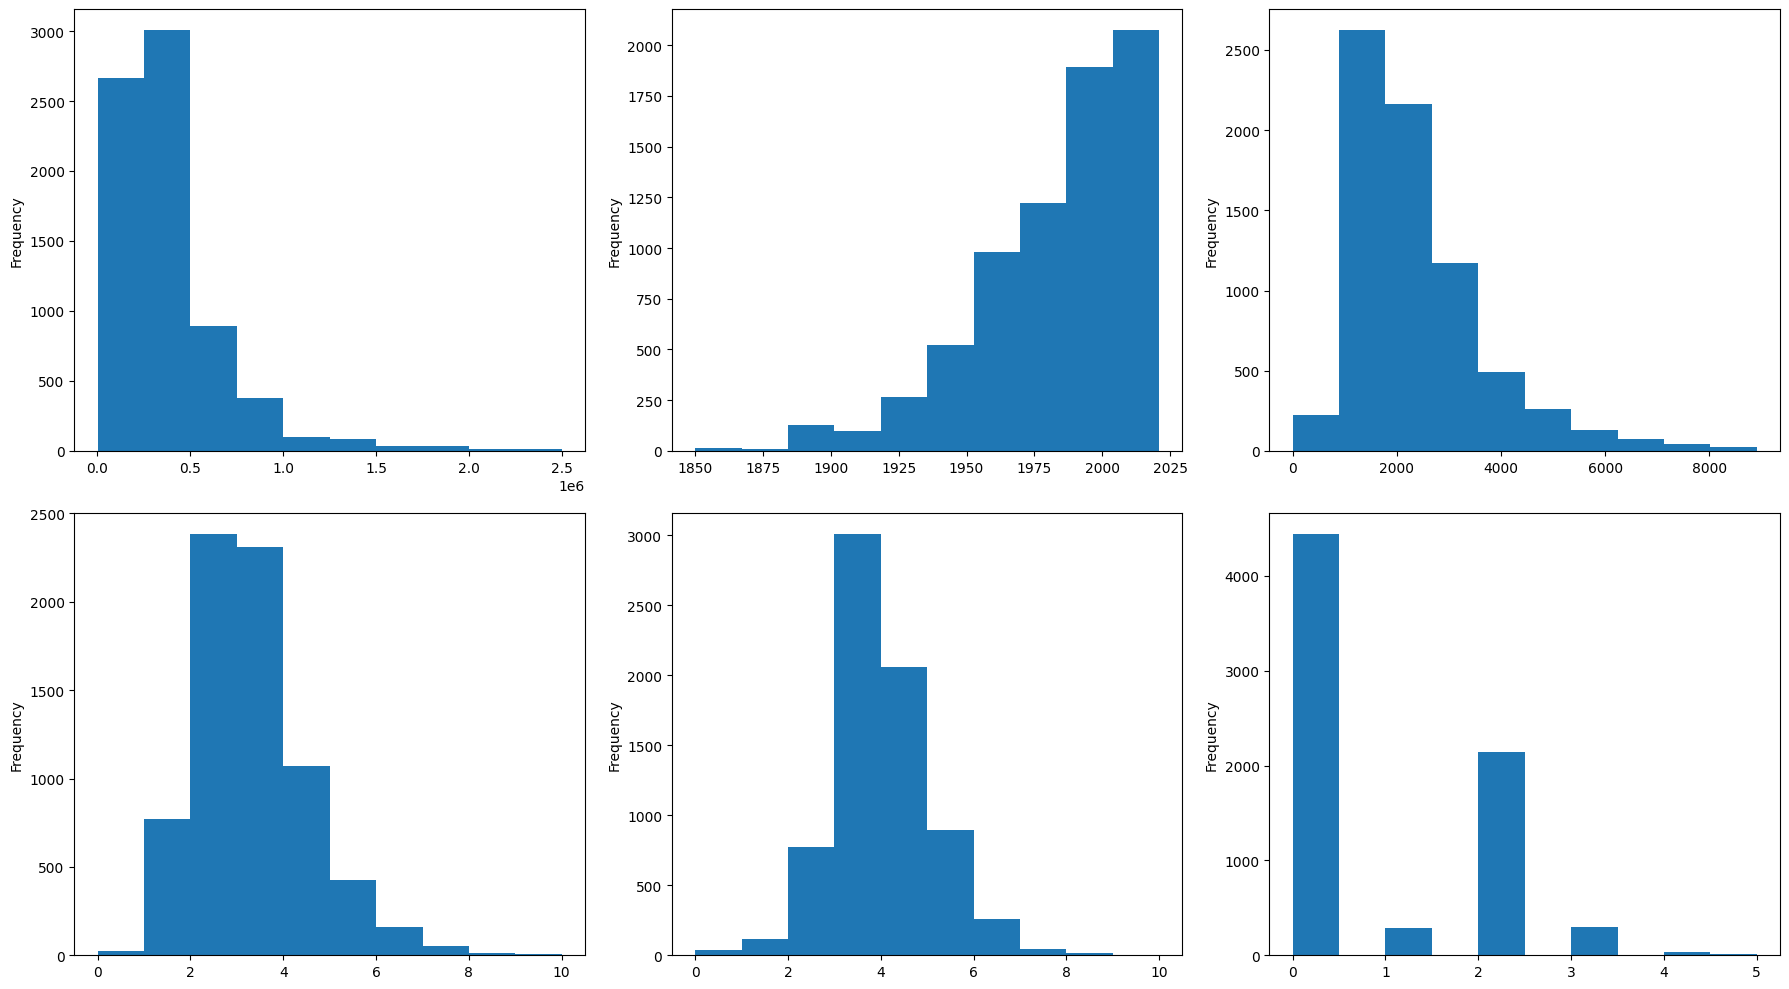

In [178]:
# These are the columns we actually want to check for outliers
columns_to_check = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

print("Columns to check for outliers:")
print(columns_to_check)

import matplotlib.pyplot as plt

numeric_cols = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

fig = plt.figure(figsize=(18, 10))
for i, column in enumerate(numeric_cols):
    sub = fig.add_subplot(2, 3, i+1)
    sub.set_xlabel(column)
    df_filtered[column].plot(kind='hist')

plt.tight_layout()
plt.show()

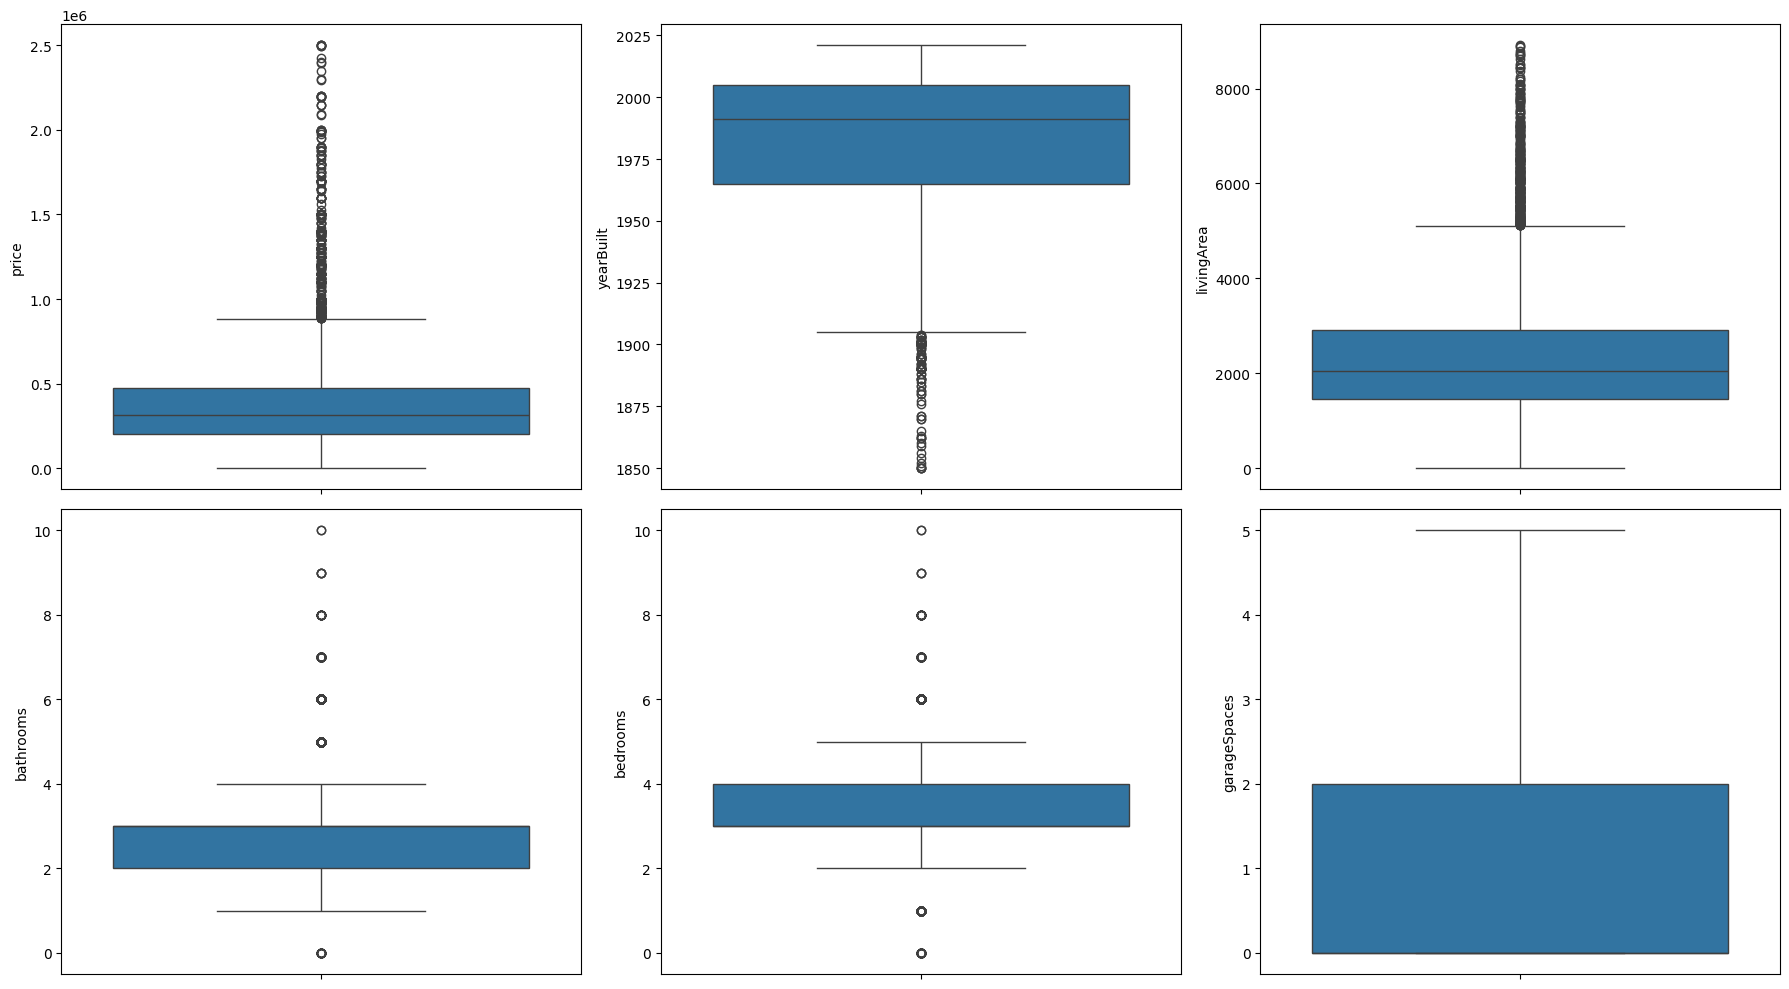

In [179]:
#Question 2 Continued
#Now that I have fixed a lot of the outliers, I created boxplots for visualization
#These box plots are not comparing the variables to the target variable, but rather checking for outliers
import seaborn as sns

numeric_cols = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

fig = plt.figure(figsize=(18, 10))
for i in range(len(numeric_cols)):
    column = numeric_cols[i]
    sub = fig.add_subplot(2, 3, i+1)
    sns.boxplot(y=df_filtered[column])

plt.tight_layout()
plt.show()

In [180]:
#Here, I still want to get an overall picture of the min and max values of the data.
# I used the following code below to generate min/max, mean, and spread of the data in each column
numeric_cols = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

for col in numeric_cols:
    print(f"\n{col}:")
    print(df_filtered[col].describe())
    print(f"Min: {df_filtered[col].min()}")
    print(f"Max: {df_filtered[col].max()}")


price:
count    7.214000e+03
mean     3.871597e+05
std      3.050532e+05
min      7.950000e+02
25%      1.999000e+05
50%      3.139000e+05
75%      4.749000e+05
max      2.499999e+06
Name: price, dtype: float64
Min: 795.0
Max: 2499999.0

yearBuilt:
count    7214.000000
mean     1983.447186
std        29.379954
min      1850.000000
25%      1965.000000
50%      1991.000000
75%      2005.000000
max      2021.000000
Name: yearBuilt, dtype: float64
Min: 1850
Max: 2021

livingArea:
count    7214.000000
mean     2374.627253
std      1296.429985
min         1.000000
25%      1457.000000
50%      2053.000000
75%      2920.750000
max      8911.000000
Name: livingArea, dtype: float64
Min: 1.0
Max: 8911.0

bathrooms:
count    7214.000000
mean        2.821597
std         1.240262
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max        10.000000
Name: bathrooms, dtype: float64
Min: 0.0
Max: 10.0

bedrooms:
count    7214.000000
mean        3.527447
std        

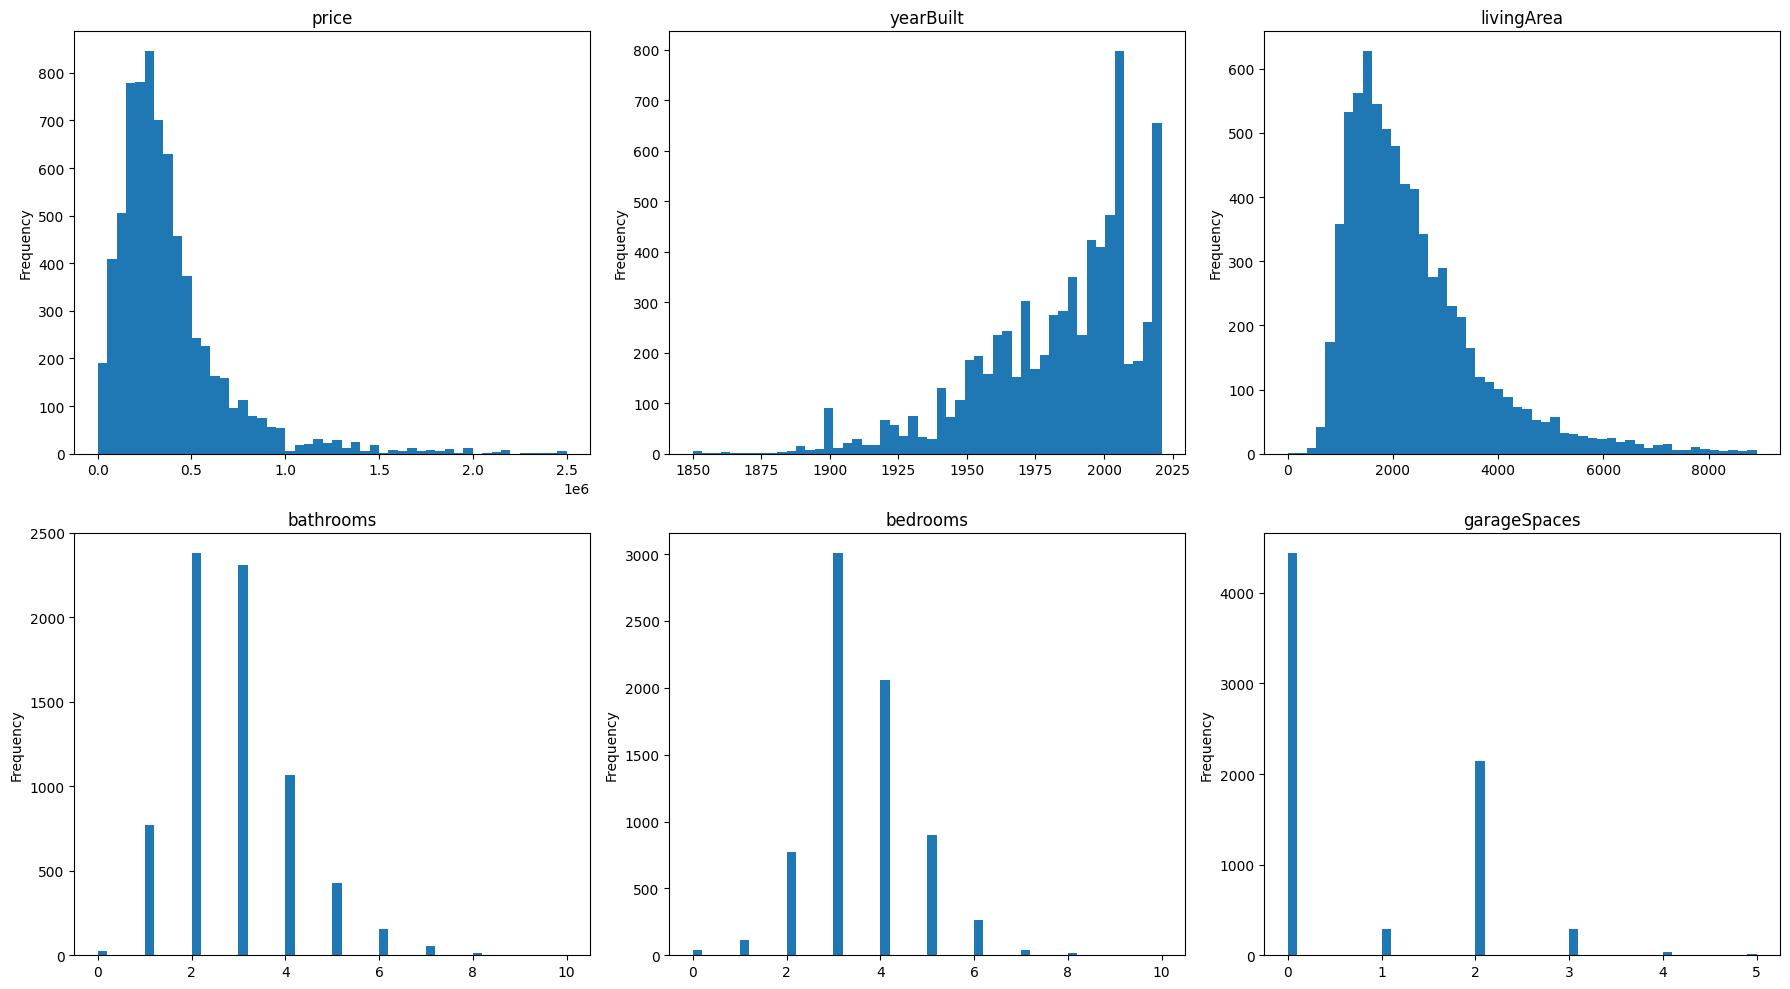

In [181]:
#Histogram for visualization of the data
import matplotlib.pyplot as plt

numeric_cols = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

fig = plt.figure(figsize=(18, 10))
for i, column in enumerate(numeric_cols):
    sub = fig.add_subplot(2, 3, i+1)
    sub.set_xlabel(column)
    sub.set_title(column)
    df_filtered[column].plot(kind='hist', bins=50)

plt.tight_layout()
plt.show()

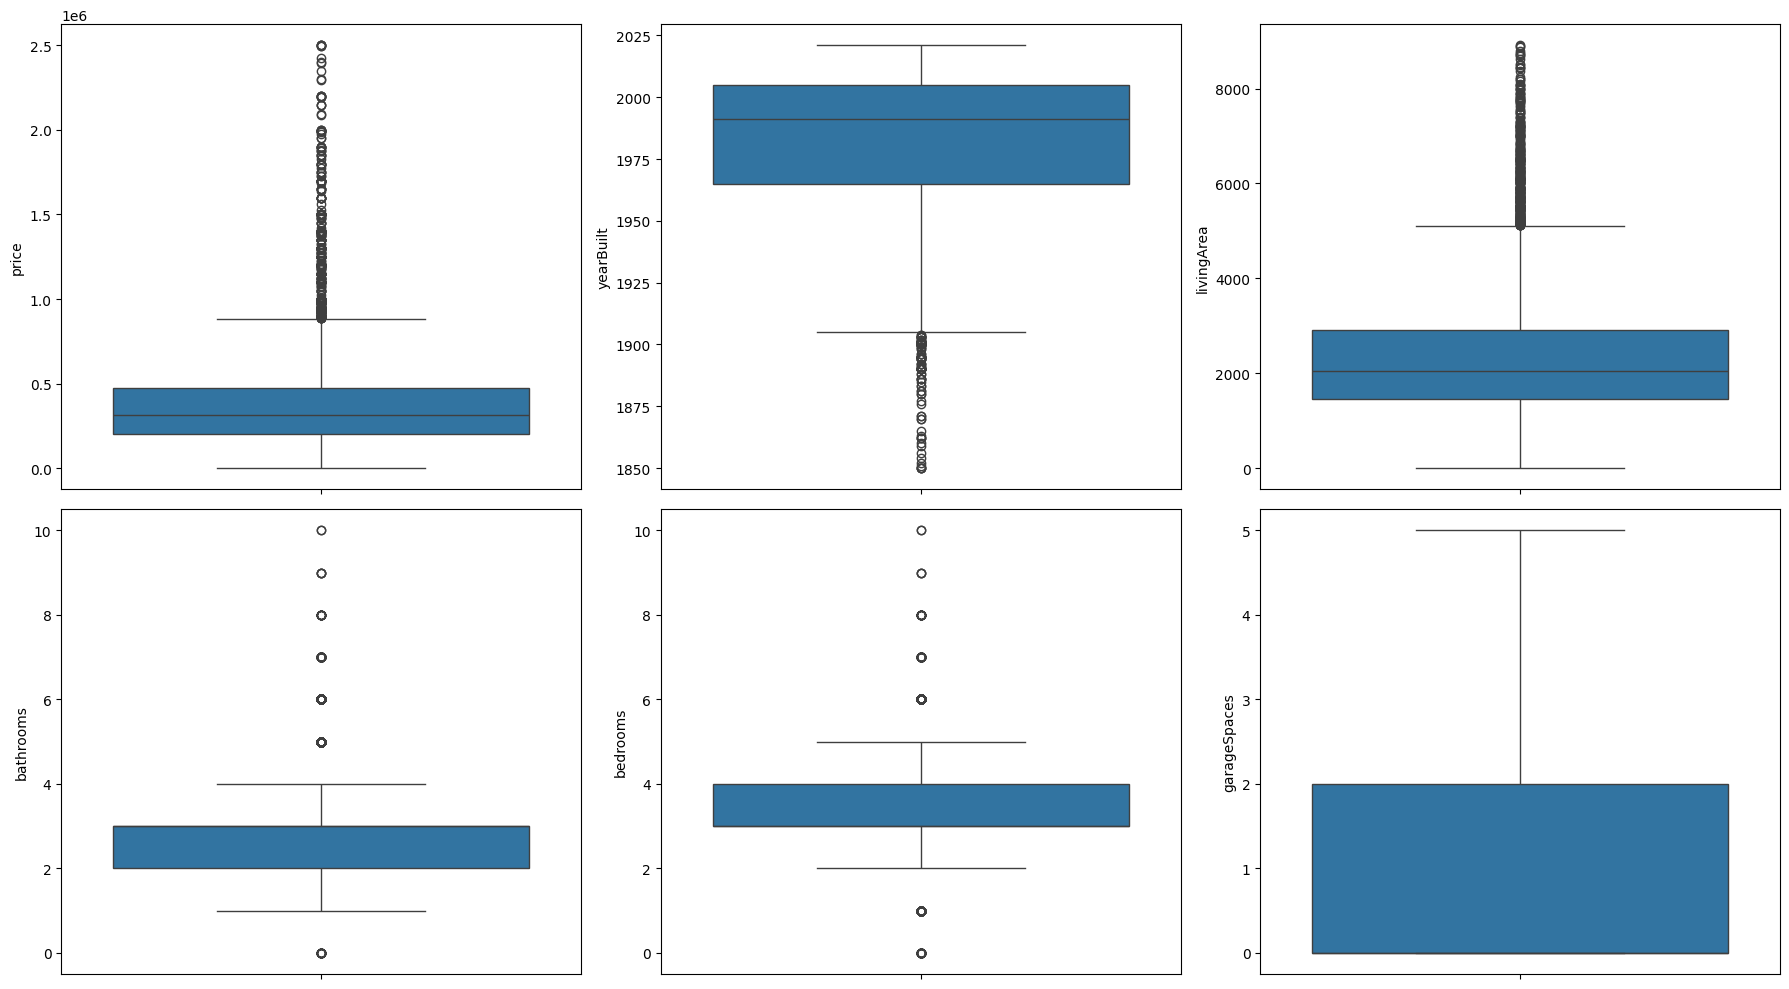

In [182]:


numeric_cols = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

fig = plt.figure(figsize=(18, 10))
for i in range(len(numeric_cols)):
    column = numeric_cols[i]
    sub = fig.add_subplot(2, 3, i+1)
    sns.boxplot(y=df_filtered[column])

plt.tight_layout()
plt.show()

In [183]:
#Question 2 Continued:
#Now I will convert categorical variables to numeric
from sklearn.preprocessing import LabelEncoder

# Make a copy to preserve original
df_encoded = df_filtered.copy()

# Label encode categorical columns
le = LabelEncoder()
cat_columns = ['homeType', 'county', 'levels']

for col in cat_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Verify it worked
print("After Label Encoding:")
print(df_encoded.head())
print("\nData types:")
print(df_encoded.dtypes)

After Label Encoding:
   is_bankOwned  is_forAuction     price  yearBuilt  livingArea  bathrooms  \
0             0              0  169900.0       1985      2302.0        3.0   
1             0              0  159000.0       1910      2864.0        2.0   
2             0              0   45000.0       1945       728.0        1.0   
3             0              0  165000.0       1971      1620.0        2.0   
5             0              0  173500.0       1980      1512.0        2.0   

   bedrooms  parking  garageSpaces  hasGarage  levels  pool  spa  \
0       4.0        0           0.0          0       9     0    0   
1       4.0        0           0.0          0       9     0    0   
2       1.0        1           0.0          0       9     0    0   
3       2.0        0           0.0          0       9     0    0   
5       3.0        0           0.0          0       9     0    0   

   isNewConstruction  hasPetsAllowed  homeType  county  
0                  0               0       

In [184]:
#Check the data types to make sure categorical variables were converted properly
print(df_encoded.dtypes)

is_bankOwned           int64
is_forAuction          int64
price                float64
yearBuilt              int64
livingArea           float64
bathrooms            float64
bedrooms             float64
parking                int64
garageSpaces         float64
hasGarage              int64
levels                 int64
pool                   int64
spa                    int64
isNewConstruction      int64
hasPetsAllowed         int64
homeType               int64
county                 int64
dtype: object


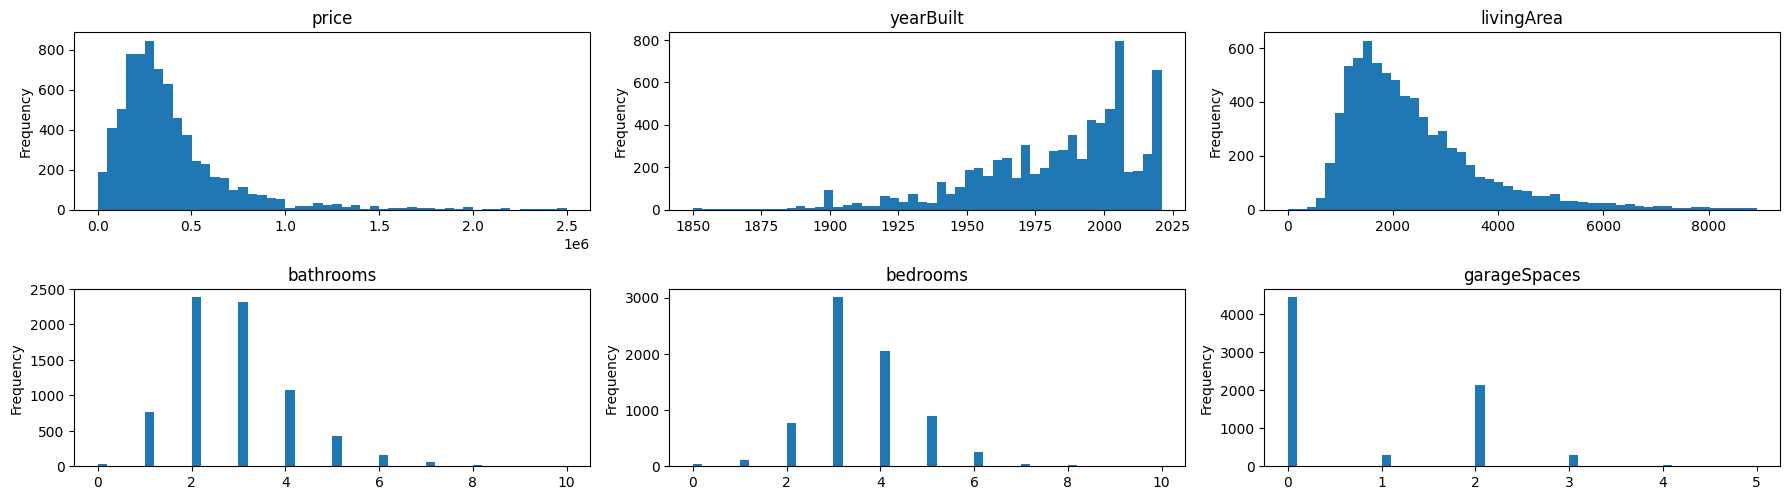

In [185]:
import matplotlib.pyplot as plt

numeric_cols = ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'garageSpaces']

fig = plt.figure(figsize=(18, 10))
for i, column in enumerate(numeric_cols):
    sub = fig.add_subplot(4, 3, i+1)
    sub.set_xlabel(column)
    sub.set_title(column)
    df_encoded[column].plot(kind='hist', bins=50)

plt.tight_layout()
plt.show()

At this point, I think the data looks pretty good. There are some outliers that remain. However, I removed the extreme ones and the outliers that are left are within the normal range for real-estate. I think if I continue to remove outliers, it will alter the our results.

In [186]:
#Question 3
#Now I will begin comparing the data to the target variable.
#Below is my code for the ANOVA test
from sklearn.feature_selection import SelectKBest, f_regression
import numpy as np

# Separate features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# ANOVA F-test
fs = SelectKBest(score_func=f_regression, k='all')
fs.fit(X, y)

# Create results dataframe
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': fs.scores_,
    'P-value': fs.pvalues_
}).sort_values('F-Score', ascending=False)

print("ANOVA F-test Results:")
print(feature_scores)

# Show insignificant features
insignificant = feature_scores[feature_scores['P-value'] > 0.05]
print(f"\n{len(insignificant)} insignificant features (p > 0.05):")
print(insignificant)

ANOVA F-test Results:
              Feature      F-Score        P-value
3          livingArea  6507.291543   0.000000e+00
4           bathrooms  5273.695884   0.000000e+00
5            bedrooms  1569.277398  1.062711e-310
7        garageSpaces  1118.237225  4.645337e-228
8           hasGarage   869.616265  1.468262e-180
11                spa   488.189836  9.902014e-105
2           yearBuilt   393.729390   2.342705e-85
10               pool   329.073525   5.977883e-72
6             parking   319.670394   5.451476e-70
15             county    48.496580   3.600334e-12
12  isNewConstruction    40.725174   1.860618e-10
14           homeType    26.860869   2.245758e-07
9              levels     3.089682   7.883265e-02
1       is_forAuction     1.050645   3.053930e-01
0        is_bankOwned     0.555044   4.562884e-01
13     hasPetsAllowed     0.005814   9.392216e-01

4 insignificant features (p > 0.05):
           Feature   F-Score   P-value
9           levels  3.089682  0.078833
1    is_forA

In [187]:
# Check variance of all features
variances = X.var().sort_values()
print("Features with lowest variance:")
print(variances.head(10))

# Identify very low variance (< 0.01)
low_variance = variances[variances < 0.01]
print(f"\nFeatures with very low variance (< 0.01):")
print(low_variance)

Features with lowest variance:
is_forAuction        0.000139
is_bankOwned         0.000139
hasPetsAllowed       0.006337
isNewConstruction    0.055450
pool                 0.072897
spa                  0.085388
parking              0.208789
homeType             0.233265
hasGarage            0.247375
garageSpaces         1.092997
dtype: float64

Features with very low variance (< 0.01):
is_forAuction     0.000139
is_bankOwned      0.000139
hasPetsAllowed    0.006337
dtype: float64


In [188]:
#Here I will check the correlation matrix
print(df_encoded.corr()['price'].sort_values(ascending=False))

price                1.000000
livingArea           0.688707
bathrooms            0.649907
bedrooms             0.422738
garageSpaces         0.366386
hasGarage            0.328031
spa                  0.251793
yearBuilt            0.227525
pool                 0.208896
parking              0.206018
isNewConstruction    0.074934
homeType             0.060915
hasPetsAllowed      -0.000898
is_bankOwned        -0.008772
is_forAuction       -0.012069
levels              -0.020694
county              -0.081728
Name: price, dtype: float64


The ANOVA test and the Correlation Matrix agree that living area, bedrooms, and bathrooms are the strongest of the predictors. In contrast, county, allows pets, levels, etc. have the lowest correlation with price.
#
In addition, is_forAuction, is_bankOwned, hasPetsAllowed all have low variation. The variable levels also had a low f-score from the ANOVA test. I will drop these four from the dataset next.

In [189]:
#Here I will go ahead and drop the insignificant features
df_model_clean = df_encoded.copy()

# Drop insignificant features
df_model_clean = df_model_clean.drop(columns=['levels', 'is_forAuction', 'is_bankOwned', 'hasPetsAllowed'])
#Now I will print the shape after dropping the insignificant features
print(f"Shape after dropping features: {df_model_clean.shape}")

Shape after dropping features: (7214, 13)


In [190]:
#There are so many counties in Georgia, so I will simplify them to just the top 15 for clarity
# Simplify county to top 15
top_counties = df_model_clean['county'].value_counts().head(15).index
df_model_clean['county'] = df_model_clean['county'].where(
    df_model_clean['county'].isin(top_counties), 'Other'
)

print("County simplified to top 15 + Other")

County simplified to top 15 + Other


In [191]:
#There are still way to many outliers in price, so I will use IQR to remove them
print(f"Original dataset size: {len(df_model_clean)}")

# Remove price outliers using IQR
Q1_price = df_model_clean['price'].quantile(0.25)
Q3_price = df_model_clean['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound = Q1_price - 1.5 * IQR_price
upper_bound = Q3_price + 1.5 * IQR_price

df_model_clean = df_model_clean[
    (df_model_clean['price'] >= lower_bound) &
    (df_model_clean['price'] <= upper_bound)
]

print(f"After price outlier removal: {len(df_model_clean)}")
df_model_clean['price'].describe()


Original dataset size: 7214
After price outlier removal: 6784


,price
count,6784.000000
mean,330073.318101
std,186592.346592
min,795.000000
25%,190000.000000
50%,299900.000000
75%,432146.250000
max,885000.000000


In [192]:
#The same is true for livingArea, there are too many outliers. I will reduce the number of outliers using IQR
# Remove livingArea outliers using IQR
Q1_area = df_model_clean['livingArea'].quantile(0.25)
Q3_area = df_model_clean['livingArea'].quantile(0.75)
IQR_area = Q3_area - Q1_area
lower_area = Q1_area - 1.5 * IQR_area
upper_area = Q3_area + 1.5 * IQR_area

df_model_clean = df_model_clean[
    (df_model_clean['livingArea'] >= lower_area) &
    (df_model_clean['livingArea'] <= upper_area)
]

print(f"After livingArea outlier removal: {len(df_model_clean)}")
print(f"Total rows removed: {len(df_encoded) - len(df_model_clean)}")

After livingArea outlier removal: 6567
Total rows removed: 647


In [193]:
#Now I will create dummy variables for homeType and county
# Create dummy variables
df_model_clean = pd.get_dummies(
    df_model_clean,
    columns=['homeType', 'county'],
    drop_first=True
)

print(f"Final shape after dummies: {df_model_clean.shape}")
print(f"Columns: {df_model_clean.columns.tolist()}")

Final shape after dummies: (6567, 29)
Columns: ['price', 'yearBuilt', 'livingArea', 'bathrooms', 'bedrooms', 'parking', 'garageSpaces', 'hasGarage', 'pool', 'spa', 'isNewConstruction', 'homeType_1', 'homeType_2', 'homeType_3', 'county_22', 'county_25', 'county_27', 'county_29', 'county_39', 'county_42', 'county_43', 'county_54', 'county_60', 'county_62', 'county_68', 'county_98', 'county_102', 'county_111', 'county_Other']


In [194]:
# Separate features and target
X = df_model_clean.drop('price', axis=1)
y = df_model_clean['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (6567, 28)
Target shape: (6567,)


In [195]:
#Question 4
#Here I will split the data into training and testing sets
#I used the train_test_split function to validate the results
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (5253, 28)
Test set: (1314, 28)


In [196]:
#The next step is to scale the data
#Linear regression benfits from sclaing the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully")

Data scaled successfully


In [197]:
#The next step iS to train the model
from sklearn.linear_model import LinearRegression

model_clean = LinearRegression()
model_clean.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [198]:
#Now we run the model and see how well it does
#Does it accurately predict the price?
#The R² and RMSE values will help us see how well the model does
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions on training and test data
y_train_pred = model_clean.predict(X_train_scaled)
y_test_pred = model_clean.predict(X_test_scaled)


print("MODEL PERFORMANCE")


# Calculate R² and RMSE
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Calculate MAE (Mean Absolute Error)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Calculate Relative MAE (as a % of average actual price)
relative_mae = test_mae / np.mean(y_test)

# Print results
print(f"\nTraining R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Training MAE: ${train_mae:,.2f}")
print(f"Test MAE: ${test_mae:,.2f}")
print(f"Relative MAE: {relative_mae:.2%}")

MODEL PERFORMANCE

Training R²: 0.5662
Test R²: 0.5514
Training RMSE: $117,221.49
Test RMSE: $117,485.87
Training MAE: $82,972.54
Test MAE: $84,479.77
Relative MAE: 26.39%


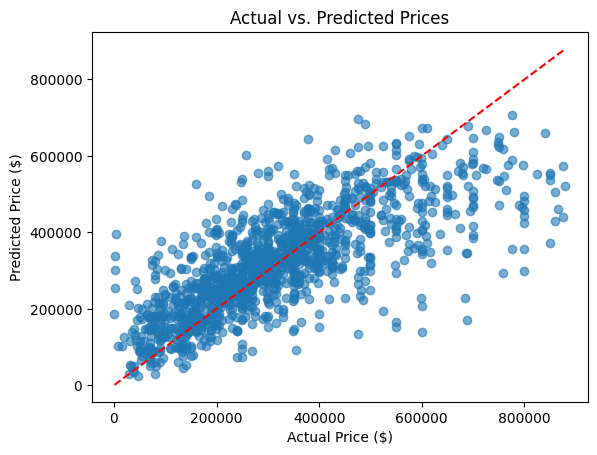

In [199]:
#Here is a Linear Regression graph to help visualize the model
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.show()

#Model Summary:
#
The results from the model are average, but not great. The R^2 value shows 0.55 which means the model accounts for 55% of the variation of home prices. It does not account for 45% of the factors that affect the price. That is good, but it is not great.
#
The RMSE(Root Mean Squared Error) value says that our predictions are off by about 117,500 on average. The RMSE value is affected by errors/outliers though, so we will also look at the MAE (Mean Absolute Error).
The MAE value says the models predictions are off by about $84,480 on average.
#
The difference between the Training R^2 value and the Testing R^2 value is very low. That is a good sign because it means the model is not overfitting.

#Project Summary:
#
Overall, I learned a lot of things from this project. Beginning with the dataset itself. I think I could have chosen better data. This data is limited in that it only covered homes listed in the first six months of 2021 in Georgia. Looking back, that is probably too limited in scope to get good results from our model.
#
In addition, the dataset had a lot of errors, odd values, and features that were not needed. This included:properties with 89 bedrooms, year built values of 9999, and over 4,000 vacant lots. I cleaned up as much of the data as I possibly could, but I wonder if that affected the accuaracy of the model.
#
The final Linear Regression model achieved an R² of 0.55, explaining 55% of price variation with a mean absolute error of $84,480. While this shows that features like livingArea, bathrooms, and county significantly predict prices, nearly half the variation remains unexplained.
#
There are several things I would try in order to improve the accuracy of this model. The first thing would be to incrementally add back some of the variables that I removed at the beginning. Variables like zipcode and buildingArea might have had more of an impact than I thought. Another change I would try is to use other models and compare. A random forest model might provide a better result comparing the features to the target variable. In summary, while the results are decent, I think they could be improved.